# 🎓 소프트웨어랩 기말고사 — GAN
## 과제: Discriminator / Generator 모델 수정 구현

**제출:** 모든 TODO 구현 → 전체 실행 → 스크린샷 → GitHub 업로드

---

### TODO 목록

| 번호 | 구현 대상 | 설명 | 난이도 |
|------|-----------|------|--------|
| ① | 하이퍼파라미터 | batch_size, num_epochs 변경표 참고 | ⭐ |
| ② | Discriminator D | 5층 Linear 아키텍처 표 참고하여 정의 | ⭐⭐⭐ |
| ③ | Generator G | 5층 Linear 아키텍처 표 참고하여 정의 | ⭐⭐⭐ |
| ④ | 학번/이름 | STUDENT_ID, STUDENT_NAME 입력 | ⭐ |

> ⚠️ `# ===== 수정 금지 =====` 구역은 변경 금지

## 📐 구현할 모델: 수정된 D / G 아키텍처

---

### Discriminator (D) — 5개 Linear 레이어

| 레이어 | 원본 D (3층) | **수정 D (5층)** |
|--------|-------------|-----------------|
| Linear 1 | 784 → **256** | 784 → **512** |
| 활성화 | LeakyReLU(0.2) | LeakyReLU(0.2) |
| Linear 2 | 256 → **256** | 512 → **256** |
| 활성화 | LeakyReLU(0.2) | LeakyReLU(0.2) |
| Linear 3 *(추가)* | — | **256 → 128** |
| 활성화 | — | LeakyReLU(0.2) |
| Linear 4 *(추가)* | — | **128 → 64** |
| 활성화 | — | LeakyReLU(0.2) |
| Linear 5 | 256 → 1 | **64 → 1** |
| 출력 활성화 | Sigmoid | Sigmoid |

```
입력 [B, 784]
  → Linear(784→512) → LeakyReLU(0.2)
  → Linear(512→256) → LeakyReLU(0.2)
  → Linear(256→128) → LeakyReLU(0.2)   
  → Linear(128→64)  → LeakyReLU(0.2)   
  → Linear(64→1)    → Sigmoid
출력 [B, 1]
```

---

### Generator (G) — 5개 Linear 레이어

| 레이어 | 원본 G (3층) | **수정 G (5층)** |
|--------|-------------|-----------------|
| Linear 1 | latent(64) → **256** | latent(64) → **256** |
| 활성화 | ReLU | ReLU |
| Linear 2 | 256 → **256** | 256 → **512** |
| 활성화 | ReLU | ReLU |
| Linear 3 *(추가)* | — | **512 → 256** |
| 활성화 | — | ReLU |
| Linear 4 *(추가)* | — | **256 → 128** |
| 활성화 | — | ReLU |
| Linear 5 | 256 → 784 | **128 → 784** |
| 출력 활성화 | Tanh | Tanh |

```
입력 z [B, 64]  (latent_size=64)
  → Linear(64→256)  → ReLU
  → Linear(256→512) → ReLU
  → Linear(512→256) → ReLU  
  → Linear(256→128) → ReLU   
  → Linear(128→784) → Tanh
출력 [B, 784]
```

---

### 하이퍼파라미터

| 항목 | 원본 | **수정** |
|------|------|---------|
| latent_size | 64 | 64 *(동일)* |
| batch_size | 100 | **128** |
| num_epochs | 200 | **20** |


## [1] 환경 설정 *(수정 금지)*

In [1]:
import os
import torch
import torchvision
import torch.nn as nn
from torchvision import transforms
from torchvision.utils import save_image
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

sample_dir = 'samples'
os.makedirs(sample_dir, exist_ok=True)


사용 디바이스: cuda


## [2] TODO ① — 하이퍼파라미터 & 학번 입력

In [2]:
# TODO ① : 하이퍼파라미터 (변경표 참고)
latent_size = 64          # 수정 금지
num_epochs  = 20         # ← 수정 대상
batch_size  = 128         # ← 수정 대상
image_size  = 784         # 수정 금지

# TODO ④ : 학번/이름 (필수)
STUDENT_ID   = "2024105626" # (e.g., 20000000000)
STUDENT_NAME = "DOWOO KIM" # (e.g., Hong Gil Dong)

# ===== 수정 금지 =====
print(f"latent_size={latent_size}  batch_size={batch_size}  num_epochs={num_epochs}")
print(f"학번: {STUDENT_ID}  이름: {STUDENT_NAME}")
# ===== 수정 금지 끝 =====


latent_size=64  batch_size=128  num_epochs=20
학번: 2024105626  이름: DOWOO KIM


## [3] 데이터 로딩 *(수정 금지)*

In [3]:
# ===== 수정 금지 =====
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
mnist = torchvision.datasets.MNIST(root='data/', train=True, transform=transform, download=True)
# ===== 수정 금지 끝 =====


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.29MB/s]


In [4]:
# ===== 수정 금지 =====
data_loader = torch.utils.data.DataLoader(
    dataset=mnist, batch_size=batch_size, shuffle=True)
print(f"데이터로더 스텝 수: {len(data_loader)}")
# ===== 수정 금지 끝 =====


데이터로더 스텝 수: 469


## [4] TODO ②③ — Discriminator & Generator 정의

위의 **아키텍처 표와 다이어그램**을 보고 구현하세요.
- D: 5개 Linear 레이어 + LeakyReLU(0.2) + Sigmoid
- G: 5개 Linear 레이어 + ReLU + Tanh

In [5]:
# TODO ② : 수정된 Discriminator D
# 784 → 512 → 256 → 128 → 64 → 1
D = nn.Sequential(
    nn.Linear(784,512),
    nn.LeakyReLU(0.2),
    nn.Linear(512,256),
    nn.LeakyReLU(0.2),
    nn.Linear(256,128),
    nn.LeakyReLU(0.2),
    nn.Linear(128,64),
    nn.LeakyReLU(0.2),
    nn.Linear(64,1),
    nn.Sigmoid()
)    # ← nn.Sequential(...) 로 교체하세요

# TODO ③ : 수정된 Generator G
# 64 → 256 → 512 → 256 → 128 → 784
G = nn.Sequential(
  nn.Linear(64,256),
  nn.ReLU(),
  nn.Linear(256,512),
  nn.ReLU(),
  nn.Linear(512,256),
  nn.ReLU(),
  nn.Linear(256,128),
  nn.ReLU(),
  nn.Linear(128,784),
  nn.Tanh())
    # ← nn.Sequential(...) 로 교체하세요

# ===== 수정 금지 =====
D = D.to(device)
G = G.to(device)

criterion   = nn.BCELoss()
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.0002)
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0002)

print("D 파라미터:", sum(p.numel() for p in D.parameters()), "개")
print("G 파라미터:", sum(p.numel() for p in G.parameters()), "개")
print("D:", D)
print("G:", G)
# ===== 수정 금지 끝 =====


D 파라미터: 574465 개
G 파라미터: 413584 개
D: Sequential(
  (0): Linear(in_features=784, out_features=512, bias=True)
  (1): LeakyReLU(negative_slope=0.2)
  (2): Linear(in_features=512, out_features=256, bias=True)
  (3): LeakyReLU(negative_slope=0.2)
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): LeakyReLU(negative_slope=0.2)
  (6): Linear(in_features=128, out_features=64, bias=True)
  (7): LeakyReLU(negative_slope=0.2)
  (8): Linear(in_features=64, out_features=1, bias=True)
  (9): Sigmoid()
)
G: Sequential(
  (0): Linear(in_features=64, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=512, bias=True)
  (3): ReLU()
  (4): Linear(in_features=512, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=128, bias=True)
  (7): ReLU()
  (8): Linear(in_features=128, out_features=784, bias=True)
  (9): Tanh()
)


## [5] 학습 실행 *(수정 금지 — 스크린샷 캡처)*

Epoch[1/20] Step[200/469] d:0.0431 g:5.0199 D(x):1.00 D(G):0.04
Epoch[1/20] Step[400/469] d:0.1252 g:9.2380 D(x):0.97 D(G):0.03
Epoch[2/20] Step[200/469] d:0.0925 g:10.5230 D(x):0.98 D(G):0.03
Epoch[2/20] Step[400/469] d:0.2160 g:5.8886 D(x):0.93 D(G):0.03
Epoch[3/20] Step[200/469] d:0.2149 g:5.8316 D(x):0.90 D(G):0.04
Epoch[3/20] Step[400/469] d:0.3884 g:6.3906 D(x):0.89 D(G):0.03
Epoch[4/20] Step[200/469] d:0.4755 g:4.1837 D(x):0.82 D(G):0.12
Epoch[4/20] Step[400/469] d:0.6682 g:2.1369 D(x):0.73 D(G):0.13
Epoch[5/20] Step[200/469] d:1.3491 g:1.9402 D(x):0.77 D(G):0.44
Epoch[5/20] Step[400/469] d:0.5411 g:2.0082 D(x):0.82 D(G):0.24
Epoch[6/20] Step[200/469] d:0.4703 g:2.2599 D(x):0.87 D(G):0.20
Epoch[6/20] Step[400/469] d:0.9739 g:1.5594 D(x):0.82 D(G):0.46
Epoch[7/20] Step[200/469] d:3.4288 g:0.3528 D(x):0.34 D(G):0.78
Epoch[7/20] Step[400/469] d:2.1921 g:0.6990 D(x):0.35 D(G):0.61
Epoch[8/20] Step[200/469] d:0.7614 g:1.3282 D(x):0.78 D(G):0.34
Epoch[8/20] Step[400/469] d:0.6388 g:3.

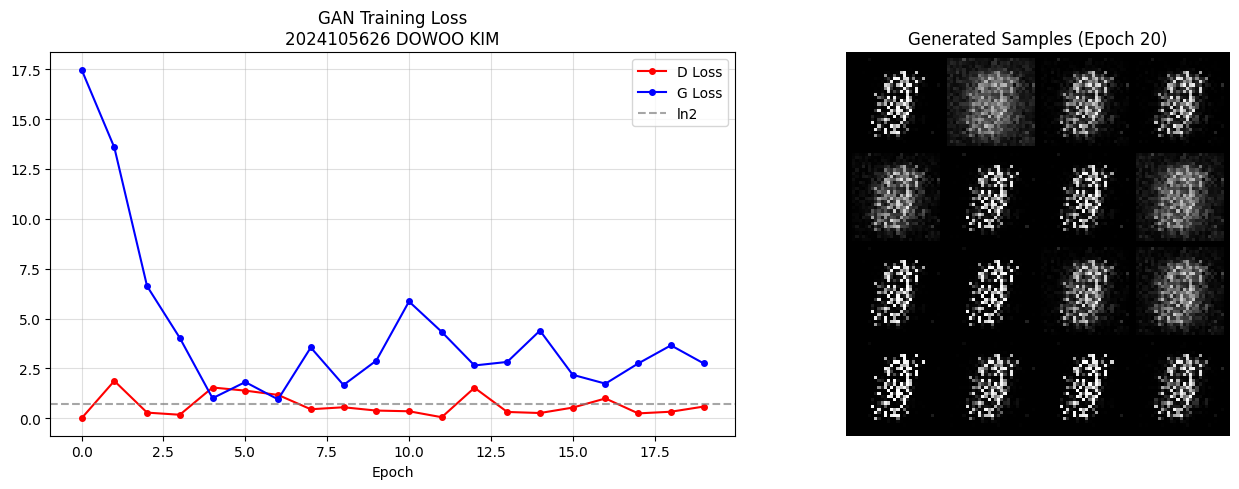

In [6]:
# ===== 수정 금지 =====
def denorm(x):
    return (x + 1) / 2

def reset_grad():
    d_optimizer.zero_grad()
    g_optimizer.zero_grad()

total_step   = len(data_loader)
d_loss_hist, g_loss_hist = [], []

for epoch in range(num_epochs):
    for i, (images, _) in enumerate(data_loader):
        # ── 실제 배치 크기 사용 (마지막 배치 오류 방지) ──────────────
        actual_batch = images.size(0)                              # ← 버그 수정
        images       = images.reshape(actual_batch, -1).to(device)
        real_labels  = torch.ones(actual_batch,  1).to(device)
        fake_labels  = torch.zeros(actual_batch, 1).to(device)

        # ── D 학습 ─────────────────────────────────────────────────
        outputs      = D(images)
        d_loss_real  = criterion(outputs, real_labels)
        real_score   = outputs

        z            = torch.randn(actual_batch, latent_size).to(device)
        fake_images  = G(z)
        outputs      = D(fake_images)
        d_loss_fake  = criterion(outputs, fake_labels)
        fake_score   = outputs

        d_loss = d_loss_real + d_loss_fake
        reset_grad()
        d_loss.backward()
        d_optimizer.step()

        # ── G 학습 ─────────────────────────────────────────────────
        z           = torch.randn(actual_batch, latent_size).to(device)
        fake_images = G(z)
        outputs     = D(fake_images)
        g_loss      = criterion(outputs, real_labels)
        reset_grad()
        g_loss.backward()
        g_optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch[{}/{}] Step[{}/{}] d:{:.4f} g:{:.4f} D(x):{:.2f} D(G):{:.2f}'.format(
                epoch+1, num_epochs, i+1, total_step,
                d_loss.item(), g_loss.item(),
                real_score.mean().item(), fake_score.mean().item()))

    d_loss_hist.append(d_loss.item())
    g_loss_hist.append(g_loss.item())

    if (epoch+1) % 10 == 0:
        fake_save = fake_images.reshape(fake_images.size(0), 1, 28, 28)
        save_image(denorm(fake_save),
                   os.path.join(sample_dir, f'fake_images-{epoch+1}.png'))

torch.save(G.state_dict(), 'G.ckpt')
torch.save(D.state_dict(), 'D.ckpt')
print("\n✅ 학습 완료!")
# ===== 수정 금지 끝 =====

# ===== 수정 금지 =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(d_loss_hist, 'r-o', markersize=4, label='D Loss')
axes[0].plot(g_loss_hist, 'b-o', markersize=4, label='G Loss')
axes[0].axhline(0.693, color='gray', linestyle='--', alpha=0.7, label='ln2')
axes[0].set_title(f'GAN Training Loss\n{STUDENT_ID} {STUDENT_NAME}', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.4)

G.eval()
with torch.no_grad():
    z_sample  = torch.randn(64, latent_size).to(device)
    fake_grid = G(z_sample).reshape(-1, 1, 28, 28)
    fake_grid = denorm(fake_grid).cpu()
grid = torchvision.utils.make_grid(fake_grid[:16], nrow=4, normalize=False)
axes[1].imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
axes[1].set_title(f'Generated Samples (Epoch {num_epochs})', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()
# ===== 수정 금지 끝 =====
